# Manual MPT plan

Scripts for more interactive, quantitative design of MSA masks initially developed for the RUBIES survey ([GO-4233](https://www.stsci.edu/jwst-program-info/program/?program=4233); [de Graaff et al. 2025](https://ui.adsabs.harvard.edu/abs/2025A%26A...697A.189D/abstract)).

## Motivation

- More fine-grained control of allocation shutters in a mask design based on a variety of optimization constraints
- RUBIES masks:
    - Design well-packed PRISM masks with discrete priority classes and continuous weights for a more objective selection function for "filler" targets
       - Weights designed to "flatten" the selection function and favor more rare sources in 3D color-mag-redshift space
    - Obtain G395M grating spectra of ~every source in the PRISM mask *plus* additional fillers, allowing trace overlaps

## Set up

1. Set up a complete parent catalog with coordinates, priorities
    - see prepare_catalog.ipynb
    - upload to APT
        - (verify that the uploaded catalog has **exactly** the same reference coordinates as the existing
2. In APT/MPT, make a plan with the full catalog near a desired center position
    - **Match the MPT "Aperture PA" to the Assigned Aperture PA in the Observation info!**
    - Make sure the dummy plan has the same set up as the actual observations, i.e., a 3-Shutter "Nod in slitlet".  The grating itself isn't quite as important, as the tool here updates the plans with the desired gratings.
    - Export the plan JSON file in the MPT planning tool
    - Run "create observation" for that plan
        - The exposure details (readout mode, etc.) aren't important as this point
    - For that observation, `File > Export > MSA Target Info [.csv]` to get the target information CSV files, e.g., `4233-obs7-exp1-c1e1n1-PRISM-CLEAR.csv`
4. The scripts below use the APT `json` and `csv` files to fit for the transformation between sky and shutter coordinates and enable custom MSA designs


The tool is currently included in this repo as a sort of "psuedo module" in the `notebooks` subdirectory that can be imported directly in this notebook, e.g, `import msaplan`.  TBD packaging it up into a more conventional package that can be `pip install`ed.

In [57]:
#  Dependencies
try:
    import grizli
except ImportError:
    ! pip install grizli[aws] msaexp tqdm

In [1]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch

from grizli import utils

from scipy.spatial import ConvexHull

import astropy.units as u
from astropy.modeling.models import Polynomial2D
from astropy.modeling.fitting import LinearLSQFitter
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u

import msaplan
import msaplan.utils
import msaplan.shutters
import msaplan.plan
import msaplan.trace
import msaplan.apt

from importlib import reload

# os.getcwd()

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [2]:
# Reference plan
# mplan = msaplan.plan.MaskPlanAPT(
#     plan_file=f'gdn_center_prism.json',
#     msa_target_csv='obs1-exp1-c1e1n1-PRISM-CLEAR.csv'
# )

mplan = msaplan.plan.MaskPlanAPT(
    plan_file=f'VENUS/PG004/pg004_wht_fill.json',
    msa_target_csv='VENUS/PG004/12581-obs1-exp1-c1e1-PRISM-CLEAR.csv'
)


VENUS/PG004/12581-obs1-exp1-c1e1-PRISM-CLEAR.csv: 71 / 74 Primary + Filler sources
    fit_velocity_aberration: 1.000070  ( 0.484 ->  0.004)


# `msaoper` files

Masks of valid slits exported from APT and applied from the ``msaoper`` reference files:
 - not stuck-open
 - not stuck-closed
 - available in a 3-shutter slitlet

Additional masks available to enforce complete spectra in PRISM & G395M.

In [3]:
# This only needs to be done once
smask = msaplan.shutters.ShutterMask()

msaoper_0017 N=67669  Ntot=67669
Valid shutters: G395M
Valid shutters: PRISM
Valid shutters: All


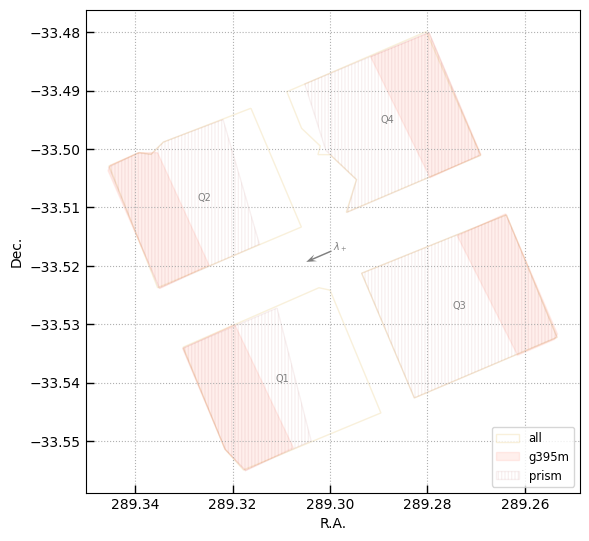

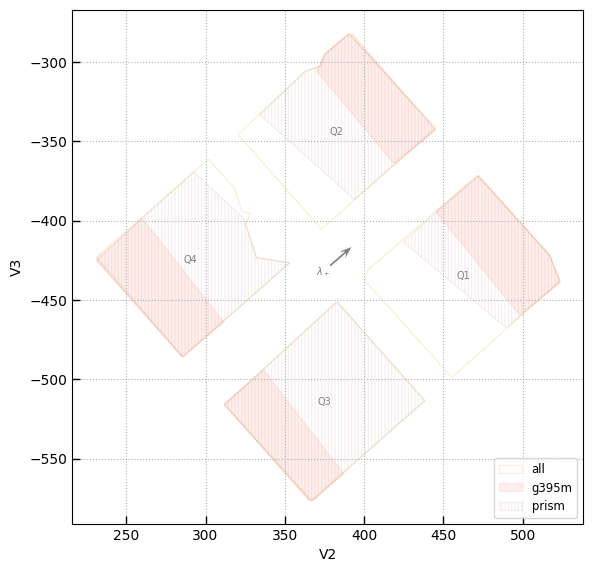

In [4]:
# Show the mask footprints

shutter_mask_footprint = msaplan.utils.shutter_mask_footprint()

# "telescope" (v2, v3) and sky coordinate systems
for i in [0,1]:
    fig = msaplan.utils.show_msa_layout(
        siaf_aper=(mplan.va_aper, None)[i],
        # figsize=(5,5),
        ascale=0.2,
        # add_labels=False, legend=False,
        label_kwargs={"alpha": 1.0, "color": "0.5", "zorder": 101, "fontsize": 7}
    )


# Read catalog

See `prepare_catalog.ipynb` for how to generate a compliant catalog from, e.g., DJA photometry + eazy photozs.

In [5]:
# vot = utils.read_catalog("gdn_imgv7.4_aw1.0_gnz7q.vot")
nrs = utils.read_catalog("VENUS/PG004/pg004_v1_260529.vot")

   N  value     
====  ==========
   2         0.0
  11         1.0
1428         4.0
1360         6.0
 641         8.0
1511        10.0
1553        12.0
6507        17.0


[]

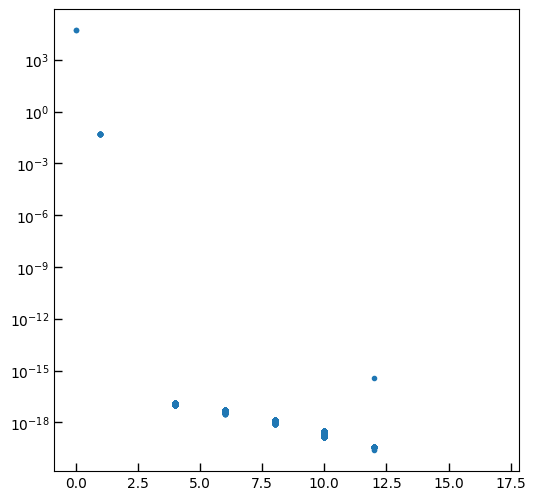

In [6]:
# Renormalize weights for optimizer below

un = utils.Unique(np.floor(nrs['Priority']))

nrs['WeightNorm'] = nrs['Weight']**3
for v in un.values:
    nrs['WeightNorm'][un[v]] /= un[v].sum()

# P1 weights
p1 = nrs['Priority'] == 1
nrs['WeightNorm'][p1] += np.maximum(nrs['WeightNorm'][p1], 2*np.max(nrs['WeightNorm'][nrs['Priority'] > 1]))

WEIGHT_COLUMN = 'Weight'
# WEIGHT_COLUMN = 'WeightNorm'

nrs['Weight2'] = (nrs['Weight']/8192)**6
nrs['Weight2'][0] *= 10000

WEIGHT_COLUMN = 'Weight2'

# plt.scatter(nrs['Priority'], nrs['Weight'])
# plt.scatter(nrs['Priority'], nrs['WeightNorm'])#/np.median(nrs['WeightNorm']))
plt.scatter(nrs['Priority'], nrs[WEIGHT_COLUMN]) #/np.median(nrs['Weight']))


plt.semilogy()

In [7]:
uni = utils.Unique(nrs['Priority'])

keep = nrs["Priority"] < 17
keep &= (nrs["Priority"] < 8) | (nrs["Priority"] == 12)

nrs = nrs[keep]

zout = utils.GTable()
for c in nrs.colnames:
    zout[c.lower()] = nrs[c]

zout.rename_column("redshift", "z_phot")
zuse = zout

   N  value     
====  ==========
   2           0
  11           1
1428           4
1360           6
 641           8
1511          10
1553          12
6507          17


In [8]:
# Copies of the table....
try:
    _ = masterx
except:
    master = zuse
    print('set master = zuse')

set master = zuse


In [9]:
# Trim
if 0:
    zout = zout[zout['priority'] < 8]
else:
    pass

zout = master
    
print(len(zout))

p3 = zout['priority'] > 2
p3 = zout['priority'] > 3.1

coo = SkyCoord(zout['ra'], zout['dec'], unit='deg,deg')

p1 = zout['priority'] <= 1
print(p1.sum(), p3.sum())

priorities = {
    0: "Must get",
    1: "Desirable",
    2: "If possible",
    2.5: "Additional flagged",
    3: 'placeholder',
    4: f'bright highz z > 3.4',
    6:  'faint highz z > 3.4',
    8: f'bright lowz  z < 3.4 ',
    10: 'faint lowz  z < 3.4',
    12: 'likely star',
    13: 'p > 2, something other than above',
    16: 'saturated, few filters, flux_radius < 1',
}

uni = utils.Unique(zout['priority'], verbose=False)
for p in uni.values:
    if p in priorities:
        print(f"p={p:>5}   {uni[p].sum():>5}  {priorities[p]}")

4354
13 4341
p=    0       2  Must get
p=    1      11  Desirable
p=    4    1428  bright highz z > 3.4
p=    6    1360  faint highz z > 3.4
p=   12    1553  likely star


# Make new MSA plan

# Reference plan

Read the files exported from APT to define the fiducial pointing.

In [10]:
# mplan = msaplan.plan.MaskPlanAPT(
#     plan_file=f'gdn_center_prism.json',
#     msa_target_csv='obs1-exp1-c1e1n1-PRISM-CLEAR.csv'
# )

mplan = msaplan.plan.MaskPlanAPT(
    plan_file=f'VENUS/PG004/pg004_wht_fill.json',
    msa_target_csv='VENUS/PG004/12581-obs1-exp1-c1e1-PRISM-CLEAR.csv'
)


VENUS/PG004/12581-obs1-exp1-c1e1-PRISM-CLEAR.csv: 71 / 74 Primary + Filler sources
    fit_velocity_aberration: 1.000070  ( 0.484 ->  0.004)


# Shutter table

The `msaplan.plan.Planner` object computes the overlap of the MSA shutters with the target catalog and produces a ``shutter_table`` that is used to derive a mask plan that can be imported into APT.


In [11]:
# Only high priority subset for optimization
opt_src = nrs[nrs['Priority'] < 3.1]

opt = msaplan.plan.MSAPointingOptimizer(mplan=mplan, source_table=opt_src, smask=smask, oversample_shutters=5)


# Mask pointings

Multiple masks can be derived for a given visit, APA, e.g., for multiple gratings or multiple separate pointings.

In [12]:
# Start with (0, 0) offsets.
# The refined offsets derived below can be entered here to save the starting point.

offsets = utils.read_catalog("""pointing, disp_offset, spat_offset, center_tolerance
pg004_p1          , -0.103 ,   0.681,  0.10
pg004_p2          , 123.851 ,   4.114,  0.10
""", format="csv")

pointing = 'pg004_p1'

#########
# This will be used to make a subdirectory for the masks calculated here
plan_version = "pg004_202606.1"

if not os.path.exists(plan_version):
    os.makedirs(plan_version)
    
offsets

pointing,disp_offset,spat_offset,center_tolerance
str8,float64,float64,float64
pg004_p1,-0.103,0.681,0.1
pg004_p2,123.851,4.114,0.1


In [13]:
# Existing spectra from the DJA, which can be used to exclude from new masks if
# you want to avoid duplicates.

from grizli.aws import db

try:
    _ = dja_spec
except:
    dja_spec = db.SQL(
        """SELECT root, file, grating, ra, dec FROM nirspec_extractions where 
        (ra > 188 AND ra < 191 AND dec > 60 AND dec < 63)"""
    " AND root = 'gdn-fujimoto-v4' AND grating = 'G395M'"
# " AND grating in ('PRISM'))"
    )
    
utils.Unique(dja_spec['root'])
dja_spec

Set ROOT_PATH=/Users/gbrammer/Research/JWST/Projects/NIRSpec/rubies-msa-mask/notebooks
   N  value     
====  ==========
 290  gdn-fujimoto-v4


root,file,grating,ra,dec
str15,str49,str5,float64,float64
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_18879.spec.fits,G395M,189.08382740,62.17683880
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_39865.spec.fits,G395M,189.15861530,62.21406080
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_37393.spec.fits,G395M,189.07064740,62.20894960
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_15990.spec.fits,G395M,189.14331770,62.17014550
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_15458.spec.fits,G395M,189.12786060,62.17025970
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_13406.spec.fits,G395M,189.14436370,62.16580680
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_13481.spec.fits,G395M,189.15109410,62.16641850
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_13956.spec.fits,G395M,189.08629130,62.16695570
gdn-fujimoto-v4,gdn-fujimoto-v4_g395m-f290lp_4762_17264.spec.fits,G395M,189.07573030,62.17274290


## Planned slits

Potentially keep track of the planned slits across multiple masks in a particular program / visit.

   N  value     
====  ==========
 290  G395M     
Couldn't run SkyCoord.match_to_catalog_sky withnthneighbor
Skip  pg004_202606.1/pg004_p1_shutter_table.fits
pg004_202606.1/pg004_p2_shutter_table.fits
110 planned prism slits


(289.29212819884725, 289.2359273330607)

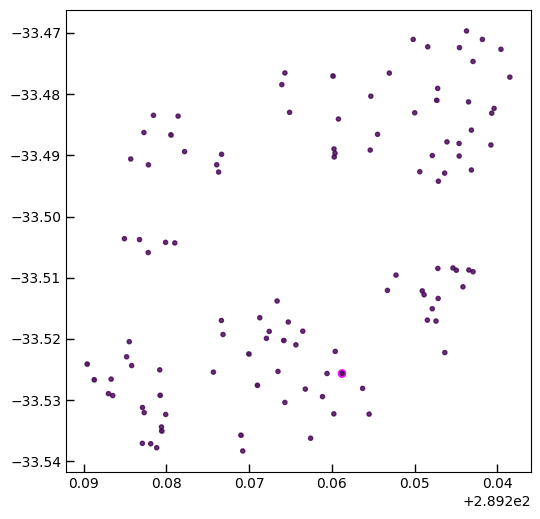

In [14]:
import glob

try:
    _ = planned_slitsx
    print('existing planned slits')
    
except:
    planned_slits = utils.GTable()
    planned_slits['id'] = nrs['ID']
    planned_slits['ra'] = nrs['RA']
    planned_slits['dec'] = nrs['Dec']
    
    planned_slits['has_prism'] = 0
    planned_slits['has_grating'] = 0
    
    un = utils.Unique(dja_spec['grating'])
    # idx, dr = dja_spec[un['PRISM']].match_to_catalog_sky(planned_slits)
    idx, dr = dja_spec[un['G395M']].match_to_catalog_sky(planned_slits)
    # planned_slits['has_grating'][dr.value < 0.3] = 1
    planned_slits['has_grating'] = 0
    
    try:
        idx, dr = dja_spec[un['PRISM']].match_to_catalog_sky(planned_slits)
        planned_slits['has_prism'][dr.value < 0.3] = 1
    except:
        pass

if 1:
    files = glob.glob(f'{plan_version}/*_shutter*fits')
    files.sort()
    
    prism_mask = ['']*len(planned_slits)
    grating_mask = ['']*len(planned_slits)
    
    for f in files:
        if pointing in f:
            print('Skip ', f)
            continue

        print(f)
        sh = utils.read_catalog(f)
        hasp = np.isin(planned_slits['id'], sh['id'][sh['ok_prism']])
        hasg = np.isin(planned_slits['id'], sh['id'][sh['ok_grating']])
    
        key = os.path.basename(f).split('_shutter')[0]
        for j in np.where(hasp)[0]:
            prism_mask[j] += key + ' '
        for j in np.where(hasg)[0]:
            grating_mask[j] += key + ' '
            
        planned_slits['has_prism'][hasp] += 1
        planned_slits['has_grating'][hasg] += 1
    
    planned_slits['prism_mask'] = prism_mask
    planned_slits['grating_mask'] = grating_mask
    print((planned_slits['has_prism'] > 0).sum(), 'planned prism slits')

pla = planned_slits['has_prism'] > 0

np1 = nrs['Priority'] < 2.2
plt.scatter(planned_slits['ra'][np1], planned_slits['dec'][np1], alpha=0.5, color='0.5')

np0 = nrs['Priority'] < 0.1
plt.scatter(planned_slits['ra'][np0], planned_slits['dec'][np0], alpha=0.9, ec='magenta', fc='None', s=100)
# print(np0.sum())
plt.scatter(planned_slits['ra'][pla], planned_slits['dec'][pla], c=planned_slits['has_prism'][pla], alpha=0.8)

plt.xlim(*plt.xlim()[::-1])

## Initialize offsets

In [15]:
best = np.where(offsets['pointing'] == pointing)[0][0]

best_disp_offset =  offsets['disp_offset'][best]
best_spat_offset = offsets['spat_offset'][best]

if 'center_tolerance' in offsets.colnames:
    center_tolerance = offsets['center_tolerance'][best]
else:
    center_tolerance = 0.7


## Optimize pointing

In [16]:
print(f'{pointing:<16}  , {best_disp_offset:6.3f} ,  {best_spat_offset:6.3f},  {center_tolerance:.2f}')

# Only P0,1,2
subset = (nrs['Priority'] < 2.1)

# Optimize over shutters with complete prism spectra
valid_key = "prism"

EXCLUDE_PLANNED = False

# Exclude if already in a plan
if ('has_prism' in planned_slits.colnames) & (EXCLUDE_PLANNED):
    print(f"Exclude {(planned_slits['has_grating'] > 0).sum()} assigned prism sources ({subset.sum()})")
    _planned = (planned_slits['has_grating'] > 0) & (nrs['Priority'] > 0)
    
    if _planned.sum() > 0:
        subset &= ~np.isin(nrs['ID'], planned_slits['id'][_planned])
        # subset &= nrs['Weight'] < 10000 - 10
        print(f"Exclude {(planned_slits['has_grating'] > 0).sum()} assigned prism sources (Final {subset.sum()})")

opt = msaplan.plan.MSAPointingOptimizer(
    mplan=mplan,
    source_table=nrs[subset],
    smask=smask,
    valid_key=valid_key,
    oversample_shutters=5,
    weight_column=WEIGHT_COLUMN
)


pg004_p1          , -0.103 ,   0.681,  0.10


In [17]:
if pointing == "pg003_p2":
    # Slide over to catch two more catalog sources for a test
    
    result = opt.evaluate_offset(
        disp_offset=best_disp_offset + 120,
        spat_offset=best_spat_offset - 10,
        simple=False,
        toler=0.11,
        plot_kwargs={"ascale": 0.3},
    )
    
    v2, v3 = opt.offset_ap.sky_to_tel(
        opt.source_table["RA"], opt.source_table["Dec"]
    )
    
    fig = result["fig"]
    ax = fig.axes[0]
    ax.plot(v2, v3, marker='x')

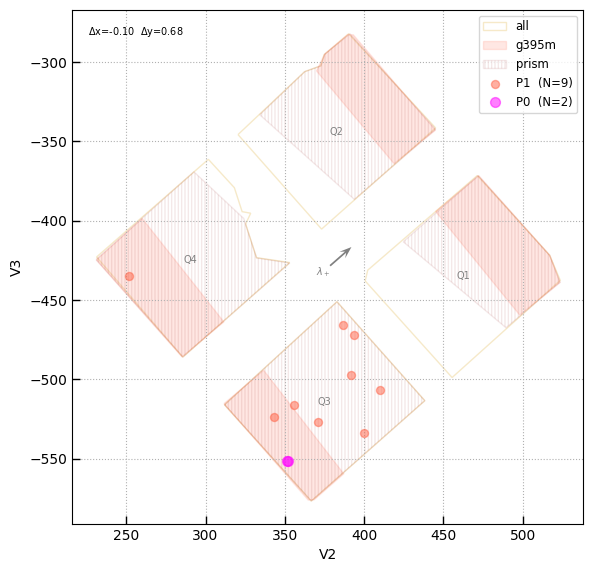

In [18]:
# Show the initial position
result = opt.evaluate_offset(
    disp_offset=best_disp_offset,
    spat_offset=best_spat_offset,
    simple=False,
    toler=0.11,
    plot_kwargs={"ascale": 0.3},
)

## Do optimization
The open circles in the figure above are P=1 sources that fall within the MSA footprint but that don't register as falling within a valid 3-shutter slitlet.  Optimize below to try to include them.

Large search, N=32  disp_offset=-0.103  spat_offset=0.681  
min_size: 1.76


1089it [00:02, 392.68it/s]


    64.00   1.0000  tol=1.41  dx=-0.103 dy=11.681  N=11 10.76 (simple=False)


1089it [00:02, 395.13it/s]


    12.80   0.2000  tol=0.28  dx=-0.303 dy=11.081  N=11 11.10 (simple=False)


1089it [00:02, 390.76it/s]


     3.20   0.0500  tol=0.11  dx=-0.053 dy=11.381  N=9 1.00 (simple=False)


1089it [00:02, 389.86it/s]


     0.16   0.0025  tol=0.11  dx=-0.065 dy=11.374  N=11 1.00 (simple=False)


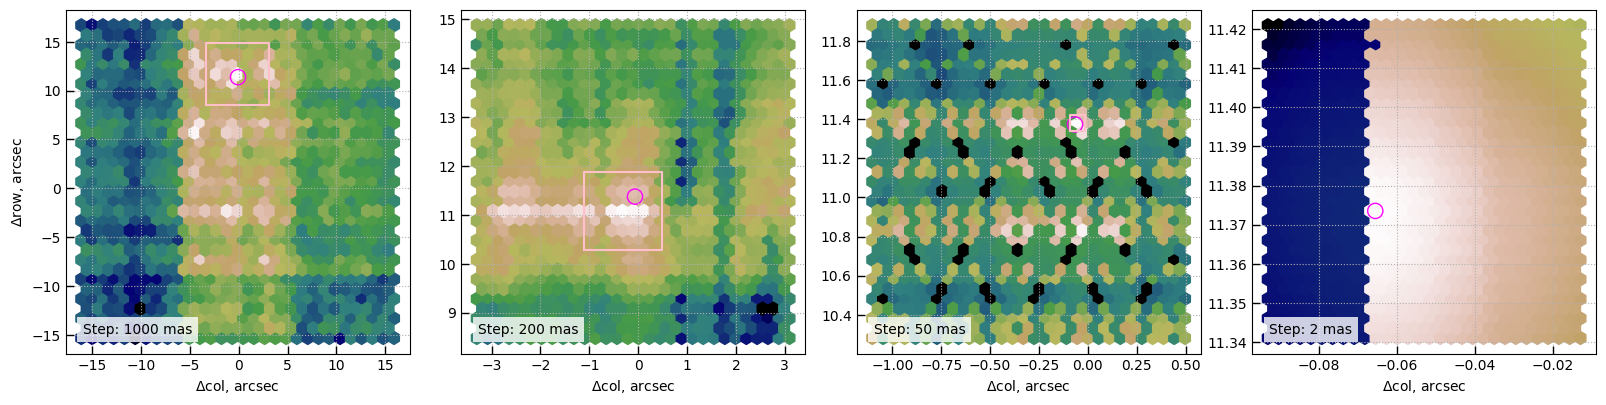

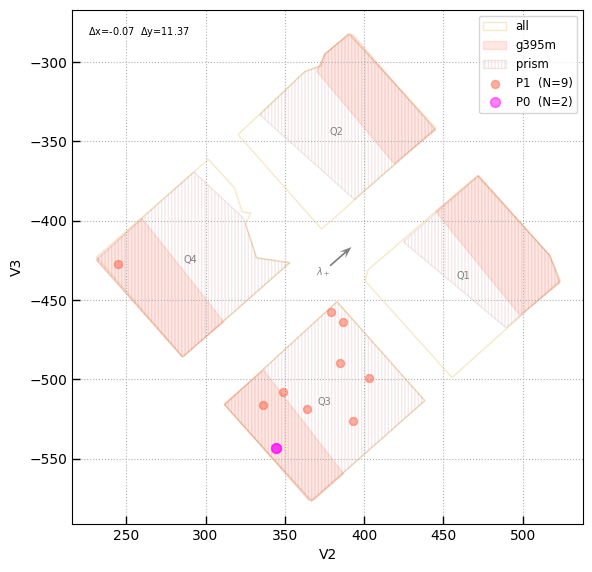

In [19]:
# reload(msaplan.plan)

opt_result = msaplan.plan.optimize_pointing(
    opt,
    disp_offset=best_disp_offset,
    spat_offset=best_spat_offset,
    large_start=1,
    optimize_type="large",
    N=32,
    random_seed=None,
    verbose=True
)

The objective function for centering the sources on shutters is very non-convex!

Shifting the pointing by just ``(-0.11, 0.66)`` arcsec keeps the original P=0 sources, and add 4 additional P=1 (now all P0, P1 points are **solid** in the plot).

In [20]:
best_disp_offset = opt_result["disp_offset"]
best_spat_offset = opt_result["spat_offset"]

print(f'\n{pointing:<16}  , {best_disp_offset:6.3f} ,  {best_spat_offset:6.3f},  {center_tolerance:.2f}\n')



pg004_p1          , -0.065 ,  11.374,  0.10



## Shutter table

The optimization function and its strategies can be used with various priority selections to determine some "optimal" telescope pointing for the catalog and assigned APA position angle. 

*With the pointing position fixed* from the optimization above, the `msaplan.plan.Planner` object computes the overlap of the MSA shutters with the target catalog and produces a ``shutter_table`` that is used to derive a mask plan that can be imported into APT.


In [21]:
print(f'\n{pointing:<16}  , {best_disp_offset:6.3f} ,  {best_spat_offset:6.3f},  {center_tolerance:.2f}\n')

bad_ids = []

bad_flagged = np.isin(nrs['ID'], bad_ids)
nrs['Priority'][bad_flagged] = 17

sample = (nrs['Priority'] < 12) & (nrs['Magnitude'] < 28.5) | (nrs['Priority'] == 11) & (~bad_flagged)
sample |= (nrs['Priority'] < 4)
sample |= np.isin(nrs['Priority'], [12.5, 13.5])

planner = msaplan.plan.Planner(
    nrs[sample],
    mplan,
    coeffs_key="prism", # grating for shutter <-> v2v3 transformation coeffs
    smask=smask,
)

shutter_table = planner.make_mask(
    disp_offset=best_disp_offset,
    spat_offset=best_spat_offset,
    cscale=center_tolerance, # 2026
    simple_mask=False,
    max_priority=None,
    faint_limit=None,
    output_type='full',
    verbose=True
)

print("")

ix = shutter_table['ix']
un = utils.Unique(planner.cat['Priority'][ix], verbose=False)

for v, c in zip(un.values, un.counts):
    if v in priorities:
        print(f'Priority {v:>5.1f} {c:>4}   {priorities[v]}')



pg004_p1          , -0.065 ,  11.374,  0.10

In quadrants:  868
Centered slits: 571

Priority   0.0    2   Must get
Priority   1.0    9   Desirable
Priority   4.0  286   bright highz z > 3.4
Priority   6.0  274   faint highz z > 3.4


In [22]:
# simple table of the sources in the catalog that can potentially be put in a shutter
# "ix" is the index of the parent catalog
shutter_table

id,ix,shutter_quadrant,shutter_row,shutter_column,raw_row,raw_col
int32,int64,int64,int64,int64,float64,float64
110,33,3,90,19,90.14919859664587,19.651520969654484
124,37,3,81,22,81.7842567988364,22.152640706406373
126,38,3,122,13,122.26311106225603,13.8018590686587
136,42,3,81,23,81.23420977920205,23.283251830990594
143,45,3,93,21,93.96310030039285,21.461376137339357
148,47,3,80,25,80.76726293917864,25.10740275875662
168,56,3,89,25,89.25284656152803,25.022222859652516
177,58,3,114,20,114.03747342355427,20.3815687719607
191,61,3,26,39,26.03161592972583,39.54608725351795


### Recenter P=0

Optionally shift the mask slightly to be sure that the P=0 sources are as best centered as possible.  The algorithm below computes the average offset of the P0 sources relative to the shutter centers and applies it after dividing by two to iterate up on the centering.

In [23]:
pix = planner.cat['Priority'][shutter_table['ix']]
p0 = pix == 0

APPLY_SHIFT = 1

if (1) & (p0.sum() > 0):
    dx_arcsec = np.mean((shutter_table['raw_row'] - np.floor(shutter_table['raw_row']))[p0] - 0.5)*0.27
    dy_arcsec = np.mean((shutter_table['raw_col'] - np.floor(shutter_table['raw_col']))[p0] - 0.5)*0.53

    print(f'x_offset: {dx_arcsec:.3f}" {dx_arcsec/0.2:.2f} shutters')
    print(f'y_offset: {dy_arcsec:.3f}" {dy_arcsec/0.53:.2f} shutters')

    if (APPLY_SHIFT):
        print('\nApply centering offset')
        best_disp_offset += dx_arcsec * 0.5
        best_spat_offset -= dy_arcsec * 0.5

        print("")
        
        # Check that still get the P0, P1 sources from before the shift
        shutter_table = planner.make_mask(
            disp_offset=best_disp_offset,
            spat_offset=best_spat_offset,
            cscale=center_tolerance, # 2026
            simple_mask=False,
            max_priority=None,
            faint_limit=None,
            output_type='full',
            verbose=True
        )
        
        ix = shutter_table['ix']
        un = utils.Unique(planner.cat['Priority'][ix], verbose=False)
        
        for v, c in zip(un.values, un.counts):
            if v in priorities:
                print(f'Priority {v:>5.1f} {c:>4}   {priorities[v]}')


x_offset: 0.043" 0.21 shutters
y_offset: -0.037" -0.07 shutters

Apply centering offset

In quadrants:  868
Centered slits: 573
Priority   0.0    2   Must get
Priority   1.0    9   Desirable
Priority   4.0  286   bright highz z > 3.4
Priority   6.0  276   faint highz z > 3.4


Optimization done, put this in the table at [#Mask pointings](#Mask-pointings) to start from there next time.

In [24]:
print(f'\n{pointing:<16}  , {best_disp_offset:6.3f} ,  {best_spat_offset:6.3f},  {center_tolerance:.2f}\n')


pg004_p1          , -0.044 ,  11.392,  0.10



### Note on slit centering

The general approach here tries to maximize the number of primary sources that get spectra even if they aren't perfectly centered in the shutters, with the idea being that there are relatively few primary sources and a spectrum with suboptimal centering is better than *no* spectrum.

(Though the centering of the highest priority targets *is* optimized above.)

p012 N= 11


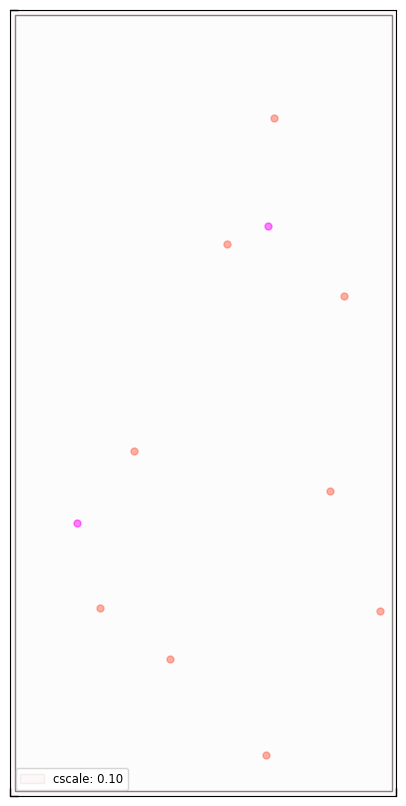

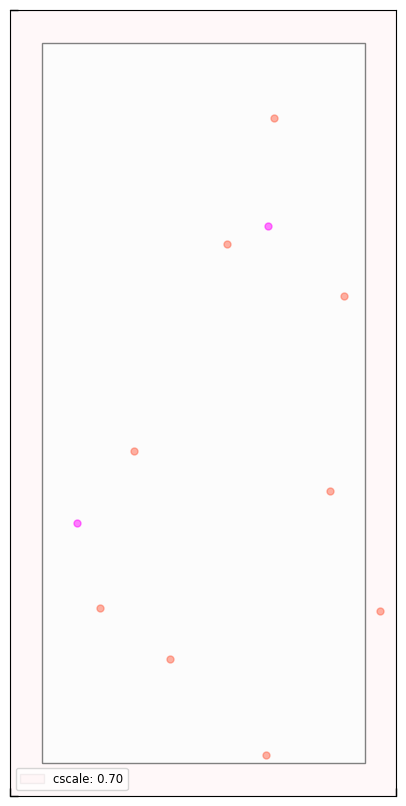

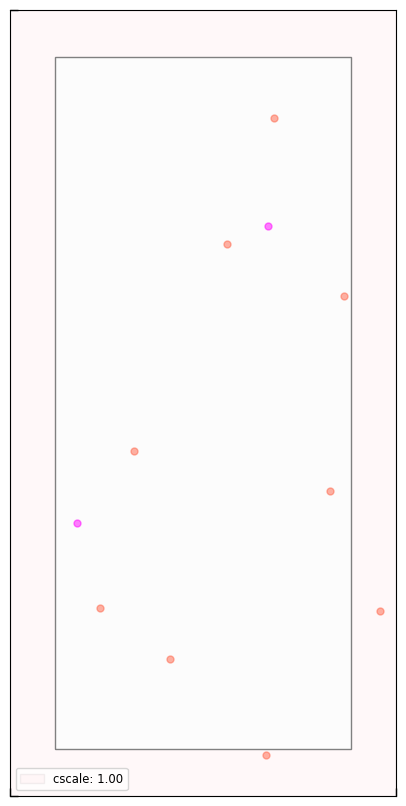

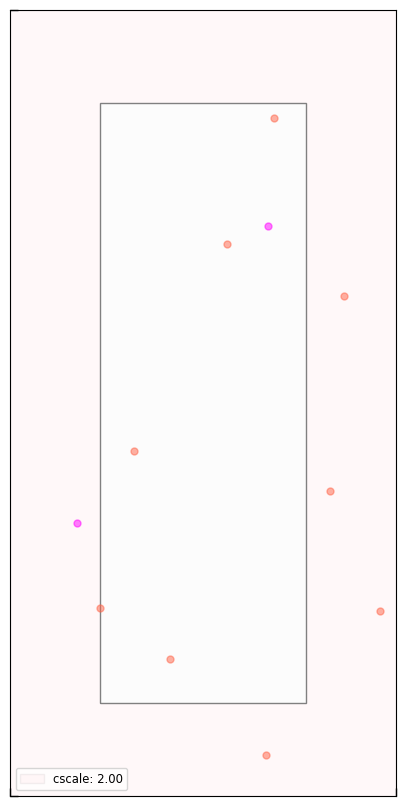

In [25]:
import msaplan.apt
# reload(msaplan.apt)

stab = msaplan.apt.ShutterTable(
    shutter_table,
    planner.cat,
    pointing_name=pointing,
    smask=smask
)

pix = stab.cat['Priority'][stab.shutter_table['ix']]
p0 = pix < 2.5

if (1) & (p0.sum() > 0):
    print('p012 N=', p0.sum())
    _ = msaplan.apt.show_shutter_centering(stab.shutter_table[p0], cscale=0.1)
    _ = msaplan.apt.show_shutter_centering(stab.shutter_table[p0], cscale=0.7)
    _ = msaplan.apt.show_shutter_centering(stab.shutter_table[p0], cscale=1.0)
    _ = msaplan.apt.show_shutter_centering(stab.shutter_table[p0], cscale=2.0)    

It's possible with the mask functions to relax the centering constraints on the primaries while imposing a more conservative constraint on the fillers, which perhaps could improve the general quality of the fillers.

Merged table: relaxed centering on P<=3, tighter centering on P>=4
Priority   0.0    2   Must get
Priority   1.0    9   Desirable
Priority   4.0  136   bright highz z > 3.4
Priority   6.0  151   faint highz z > 3.4


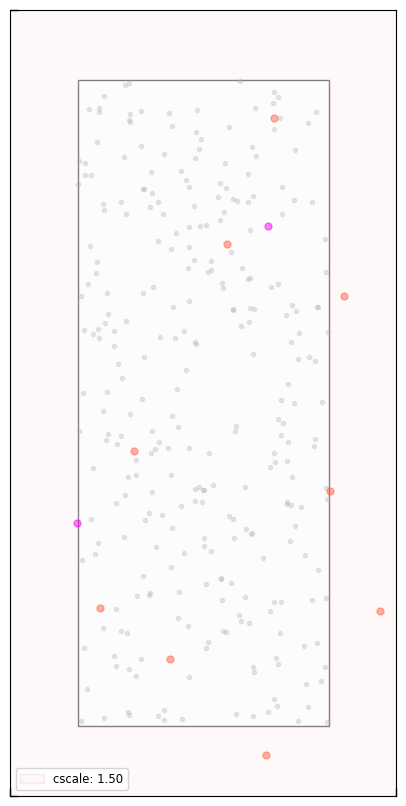

In [26]:
import astropy.table

# More conservative centering on fillers

shutter_table_relax = planner.make_mask(
    disp_offset=best_disp_offset,
    spat_offset=best_spat_offset,
    cscale=center_tolerance, # 2026
    simple_mask=False,
    max_priority=None,
    faint_limit=None,
    output_type='full',
    verbose=False
)

tight_cscale = 1.5

shutter_table_tight = planner.make_mask(
    disp_offset=best_disp_offset,
    spat_offset=best_spat_offset,
    cscale=tight_cscale,
    simple_mask=False,
    max_priority=None,
    faint_limit=None,
    output_type='full',
    verbose=False
)

shutter_table_relax["priority"] = planner.cat['Priority'][shutter_table_relax["ix"]]
shutter_table_tight["priority"] = planner.cat['Priority'][shutter_table_tight["ix"]]

shutter_table_merged = astropy.table.vstack(
    [
        shutter_table_relax[shutter_table_relax["priority"] < 4],
        shutter_table_tight[shutter_table_tight["priority"] >= 4],
    ]
)

print("Merged table: relaxed centering on P<=3, tighter centering on P>=4")

ix = shutter_table_merged['ix']
un = utils.Unique(planner.cat['Priority'][ix], verbose=False)

for v, c in zip(un.values, un.counts):
    if v in priorities:
        print(f'Priority {v:>5.1f} {c:>4}   {priorities[v]}')

stab_merged = msaplan.apt.ShutterTable(
    shutter_table_merged,
    planner.cat,
    pointing_name=pointing,
    smask=smask
)

_ = msaplan.apt.show_shutter_centering(stab_merged.shutter_table, cscale=tight_cscale)

## Set `ShutterTable`

In [27]:
if 0:
    print("Use shutter_table with relaxed centering on all sources")
    use_shutter_table = shutter_table
else:
    print("Use merged table with centered fillers")
    use_shutter_table = shutter_table_merged # centered fillers

stab = msaplan.apt.ShutterTable(
    use_shutter_table,
    planner.cat,
    pointing_name=pointing,
    smask=smask
)

Use merged table with centered fillers


## Allocate shutters based on priorities and trace overlaps

The `shutter_table` above includes every source that *could* potentially have a slit.  The functions below allocate shutters on the PRISM and grating masks based on

- The target priority classes and weights
    - The allocation starts in the P=0,1,2,3 class bins and adds as many sources as possible from these.
    - It then adds sources from the higher priority classes in order of decreasing `Weight` / priority.
- Criteria for overlapping spectral traces
- Potentially avoiding shutters where spectra could be contaminated by nearby stuck-open shutters.  I'd
  advocate only imposing the stuck-open mask for P0 sources and let P1,2 sources fall where they may.

## Empirical trace calibration for PRISM and gratings

The ``slit_cutout_metadata_202504.fits`` file contains trace information derived from individual sources in the DJA/msaexp extractions.  

The ``msaplan.trace.EmpiricalTrace`` object uses the quadratic polynomial fits to the spectral traces for making trace masks across the FoV of the MSA.  This is a relatively slow process because the code fits a trace polygon path for every source in the source catalog and then a $N \times N$ matrix that encodes the pairwise overlaps of each source with every other, along with an $N$ vector that specifies which traces overlap with one or more single-shutter stuck-open traces.

(The bottleneck is computing the trace paths and the overlaps.  Once that is stored, the shutter allocation is fast.)

In [28]:
import msaplan.trace
import msaplan.apt
# reload(msaplan.apt)
reload(msaplan.trace)

prism_trace = msaplan.trace.EmpiricalTrace(
    stab=stab,
    pad_size={0:12.5, 1:7.5},
    default_pad=7.5,
    stuck_open_pad=2.5,
    # grating='G395M', filter='F290LP',
    grating='PRISM', filter='CLEAR',
)

Optimize grating traces for for PRISM-CLEAR


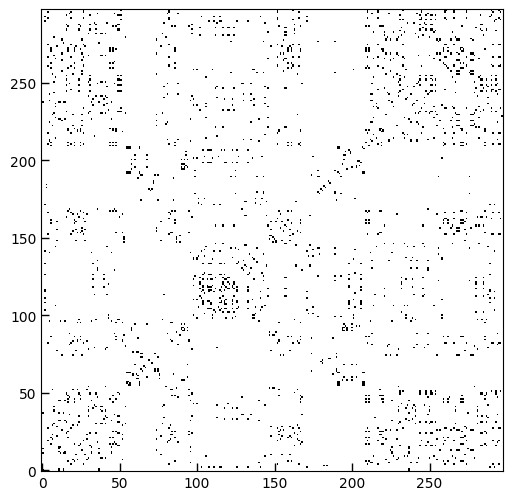

In [29]:
# show the `grating_olap` pairwise overlap matrix
so = np.argsort(prism_trace.stab.shutter_table["priority"])
plt.imshow(prism_trace.grating_olap[so,:][:,so], cmap='gray_r')

## Do the PRISM shutter allocation

- Try to include *any* P=0
- Within groups of P=0, P={1,2}, P=3, P=filler, step in order of decreasing *Weight* and allocate shutters
  to sources that satisfy the overlap constraints.
- The 

**Overlaps:**

- Allow P=1,2 to overlap with each other, but *not* P = 0
- Allow P=3 to overlap with each other, but *not* P = {0,1,2}
- Allow fillers to overlap with each other, but *not* P <= 3
- (Usually don't allow *any* overlaps for PRISM spectra.)
- When overlaps are allowed, impose an additional requirement that the *shutters* are separated by some minimum tolerance (`xpad`, `ypad`, `filler_xpad`), similar to the "Min. separation" parameter in APT.
- A larger `xpad`, `filler_xpad` will *decrease* the number of overlaps 


In [30]:
allocated_prism = prism_trace.allocate_shutters(
    xpad=7,
    ypad=2,
    ypad_allocated=2,
    force_p0_ids=[],
    filler_priorities=[3, 4, 5, 6, 7, 8],
    filler_xpad=7, allow_primary_overlap=False, allow_filler_overlap=False, # prism
    randomize_fillers=False,
)


     P0:         2 shutters (extra id=[])
   P1,2:   9 /   9 additional shutters
     P3:   0 /   0 additional shutters
Fillers:  54 / 196 additional shutters priority=[3, 4, 5, 6, 7, 8]

Total shutters:  65


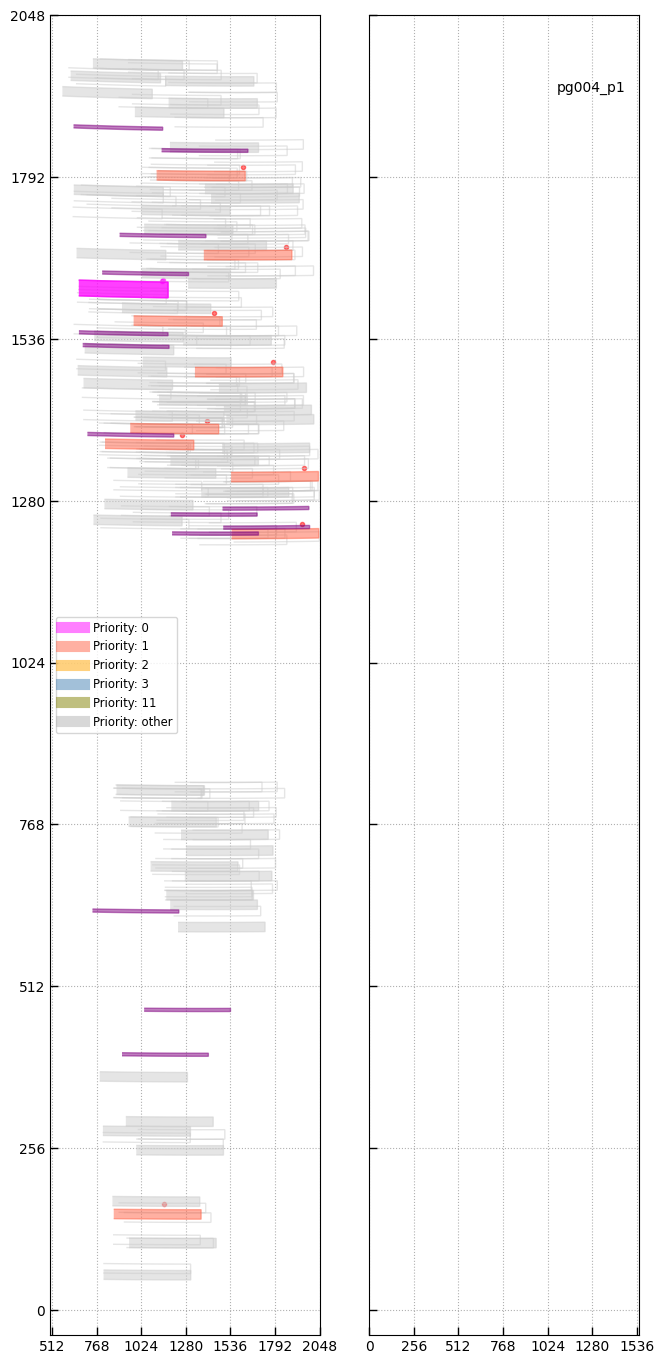

In [31]:
_ = prism_trace.plot_traces(allocated_prism, att=planner.mplan.att, show_all=True)

The P0 is a bit close to a stuck-open trace shown in purple, but is probably fine.  

If you want to manually shift the view projected on the MSA up by a few shutters (`best_spat_offset < 0`), update the "best_[]_offset" parameters and go up to [# Do optimization](#Do-optimization) to recenter.

     P0:         2 shutters (extra id=[])
   P1,2:   9 /   9 additional shutters
     P3:   0 /   0 additional shutters


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:02<00:00, 124.00it/s]


Fillers: 256 random  N=54 min=50 max=62
Fillers:  62 / 196 additional shutters priority=[3, 4, 5, 6, 7, 8]

Total shutters:  73


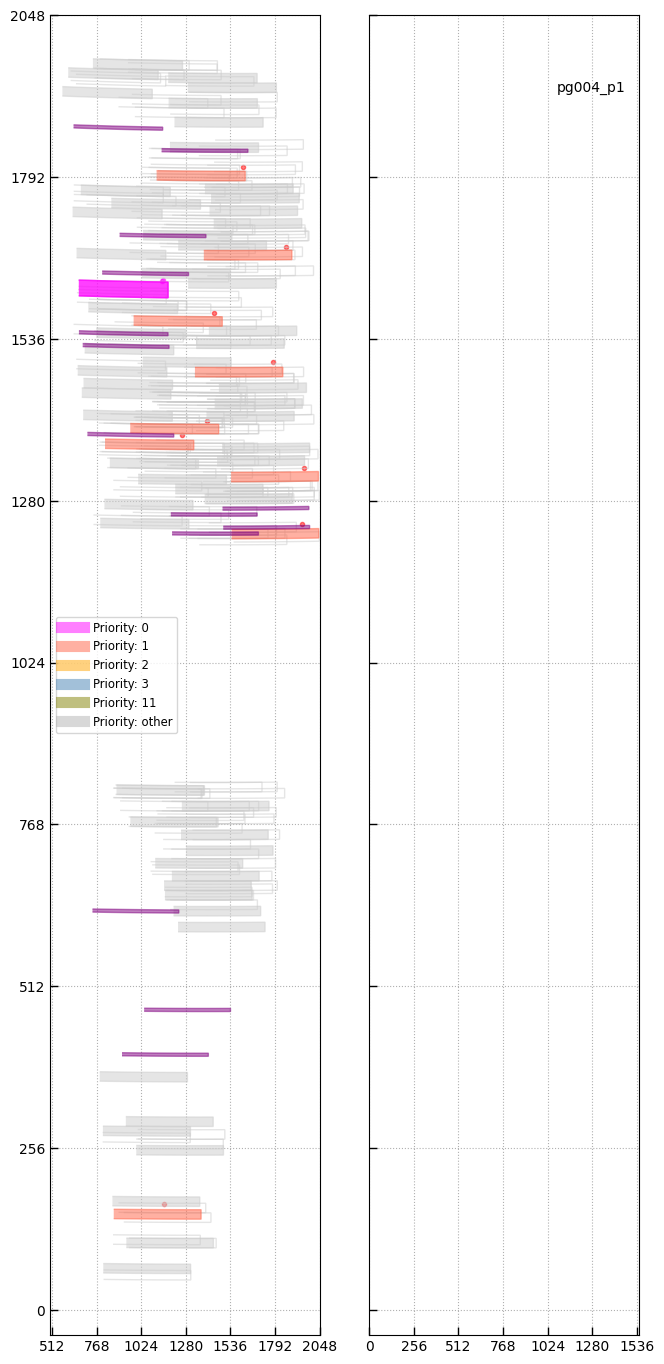

In [33]:
randomized_prism = prism_trace.allocate_shutters(
    xpad=7,
    ypad=2,
    ypad_allocated=2,
    force_p0_ids=[],
    filler_priorities=[3, 4, 5, 6, 7, 8],
    filler_xpad=7, allow_primary_overlap=False, allow_filler_overlap=False, # prism
    randomize_fillers=256,
    randomize_min_extra=3, # Only adopt the random version if it gives you at least this many additional sources
)

_ = prism_trace.plot_traces(randomized_prism, att=planner.mplan.att, show_all=True)

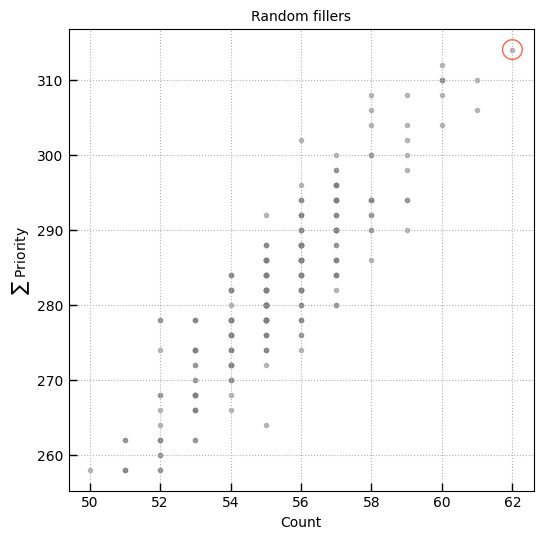

In [34]:
# "best" is min(sum(priority[count == max(count)])

plt.scatter(
    randomized_prism["random_counts"],
    randomized_prism["random_weights"],
    color="0.5", alpha=0.5,
)

plt.scatter(
    randomized_prism["random_counts"][randomized_prism["random_imax"]],
    randomized_prism["random_weights"][randomized_prism["random_imax"]],
    ec="tomato",
    fc="None",
    marker="o",
    s=200,
)

plt.title("Random fillers")
plt.xlabel("Count")
plt.ylabel(r"$\sum$ Priority")
plt.grid()


Randomizing the filler weights finds a combination with 5 more total sources than the weight-sorted allocation, which may or may not be desirable.

In [35]:
# Set the (weight-sorted) allocated prism slits to the shutter_table
prism_trace.update_shutter_table_mask(allocated_prism, which="prism")


Helper function below to summarize the allocated shutters:
- `Np` is the total number of possible sources
- `pure` is un-contaminated PRISM sources
- `grat` is for some grating
- `both` is "pure & grat" = PRISM + grating


In [36]:
stab.summary()

# p   Np  pure  grat  both
# N   298   65    0     0
# pg004_p1
P0      2    2    0     0
P1      9    9    0     0
P4    136   38    0     0
P6    151   16    0     0



## Now optimize for a grating mask

The parameters are the same as for the PRISM, but the parameters for the overlap criteria should be adjusted.

In [37]:
reload(msaplan.trace)

grating_trace = msaplan.trace.EmpiricalTrace(
    stab=stab,
    pad_size={0:12.5, 1:7.5},
    default_pad=7.5,
    stuck_open_pad=2.5,
    grating='G395M', filter='F290LP',
    # grating='PRISM', filter='CLEAR',
)

Optimize grating traces for for G395M-F290LP


     P0:         2 shutters (extra id=[])
   P1,2:   9 /   9 additional shutters
     P3:   0 /   0 additional shutters
Fillers:  42 / 179 additional shutters priority=[3, 4, 5, 6, 7, 8]

Total shutters:  53


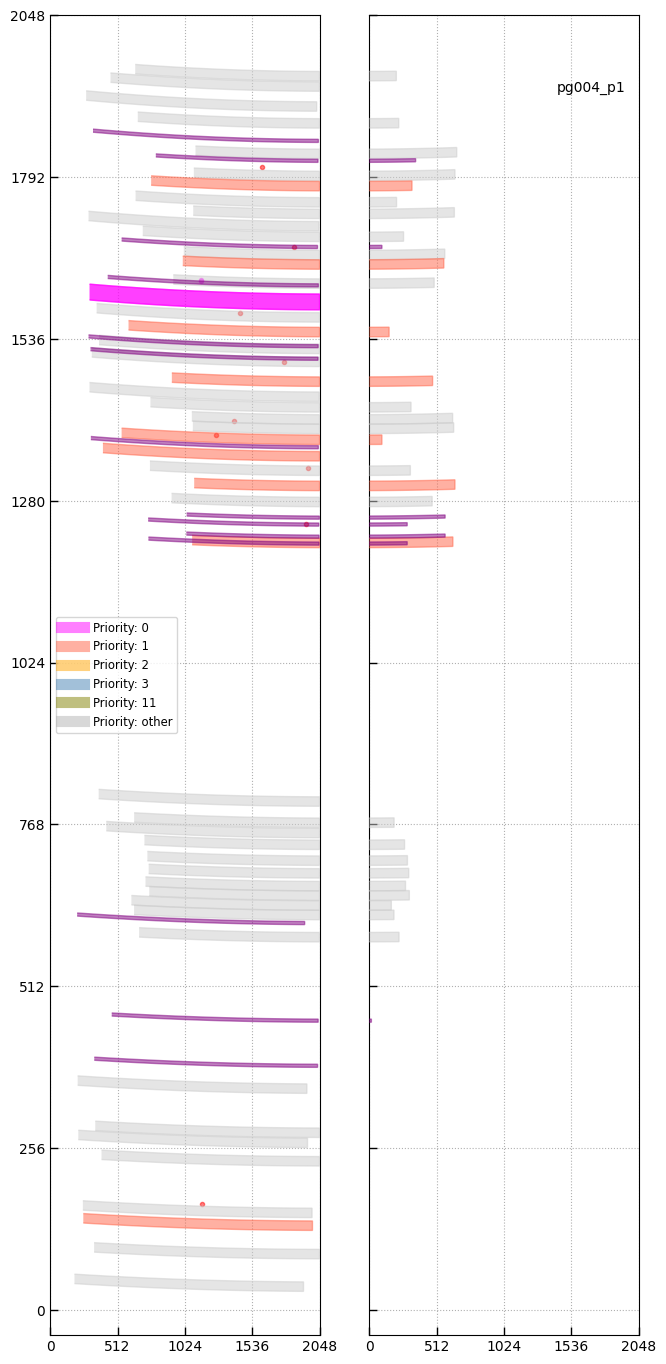

In [38]:
# No grating overlaps allowed....
allocated_grating = grating_trace.allocate_shutters(
    xpad=7,
    ypad=2,
    ypad_allocated=2,
    force_p0_ids=[],
    filler_priorities=[3, 4, 5, 6, 7, 8],
    filler_xpad=7,
    allow_primary_overlap=True,    # Primaries overlapping each other, shouldn't be many
    allow_filler_overlap=False,    # No filler overlaps
    allow_filler_stuck_open=False, # And no stuck-open contamination
    randomize_fillers=False,
    initial_mask=None
)

_ = grating_trace.plot_traces(allocated_grating, att=planner.mplan.att)

The example above allocates the grating shutters from scratch based on the target priorities and the overlap criteria.

The `initial_mask="prism"` parameter below is used to *start* with the shutters that were allocated above for the PRISM mask to ensure as many sources as possible have both grating and PRISM spectra.  Sources are removed from the PRISM mask whose *grating* spectra would overlap the primary P=0,1,2,3 sources.

allocate_shutters: initial mask from prism
allocate_shutters: orig=65 clean_primary=54
     P0:         0 shutters (extra id=[])
   P1,2:   0 /   0 additional shutters
     P3:   0 /   0 additional shutters
Fillers:  99 / 136 additional shutters priority=[3, 4, 5, 6, 7, 8]

Total shutters:  153


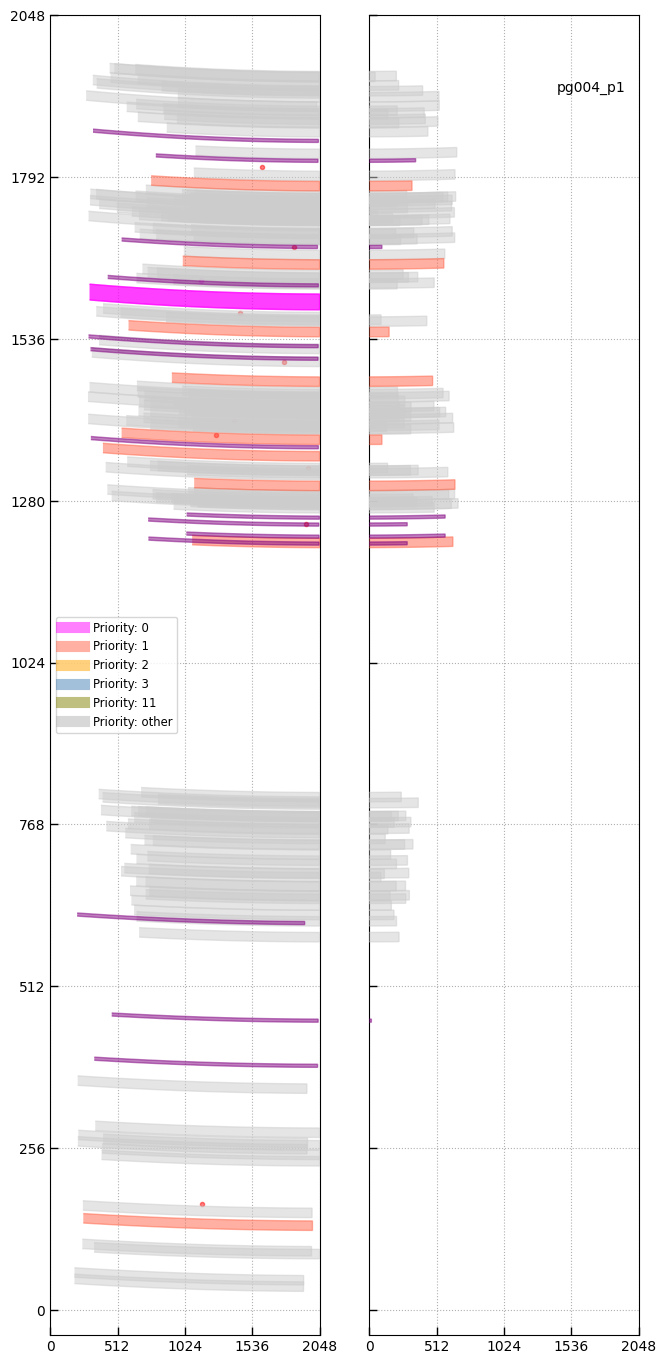

In [39]:
# Permissive overlaps: filler_xpad=10
allocated_grating = grating_trace.allocate_shutters(
    xpad=7,
    ypad=2,
    ypad_allocated=2,
    force_p0_ids=[],
    filler_priorities=[3, 4, 5, 6, 7, 8],
    filler_xpad=10, allow_primary_overlap=True, allow_filler_overlap=True, # grating    
    randomize_fillers=False,
    initial_mask="prism"
)

_ = grating_trace.plot_traces(allocated_grating, att=planner.mplan.att)

The `filler_xpad=10` parameter above alows for fairly extreme overlaps of the filler sources.  While it is generally probably *possible* to extract useful information for emission line sources in these cases (see, e.g., DarkHorse), it's probably best to be a bit more conservative with the overlaps.

Furthermore, this example VENUS catalog that doesn't completely fill the MSA FoV doesn't necessarily show the full extent of the overlaps.

allocate_shutters: initial mask from prism
allocate_shutters: orig=65 clean_primary=54
     P0:         0 shutters (extra id=[])
   P1,2:   0 /   0 additional shutters
     P3:   0 /   0 additional shutters
Fillers:  48 / 136 additional shutters priority=[3, 4, 5, 6, 7, 8]

Total shutters:  102


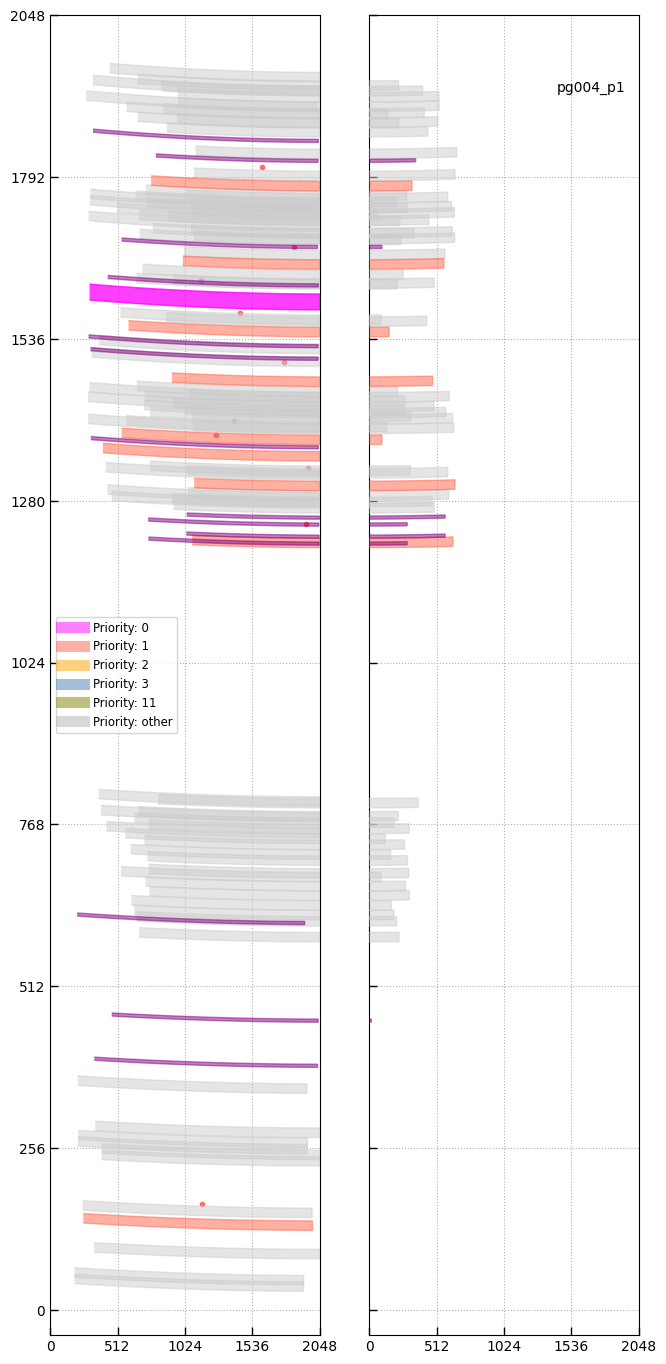

In [40]:
allocated_grating = grating_trace.allocate_shutters(
    xpad=7,
    ypad=2,
    ypad_allocated=2,
    force_p0_ids=[],
    filler_priorities=[3, 4, 5, 6, 7, 8],
    filler_xpad=80, allow_primary_overlap=True, allow_filler_overlap=True, # grating    
    randomize_fillers=False,
    initial_mask="prism"
)

_ = grating_trace.plot_traces(allocated_grating, att=planner.mplan.att)

In [41]:
grating_trace.update_shutter_table_mask(allocated_grating, which="grating")

In [42]:
grating_trace.stab.summary()

# p   Np  pure  grat  both
# N   298   65  102    54
# pg004_p1
P0      2    2    2     2
P1      9    9    9     9
P4    136   38   60    32
P6    151   16   31    11



## Check wavelength ranges

NaN in the table below usually just means that a trace is fully on a single detector.

Note for the large offset of `pg004_p2` that the P0 source is split by the detector gap!

In [43]:
sub = allocated_prism["clean_mask"] & (prism_trace.stab.shutter_table["priority"] < 0.5)

p012_info = prism_trace.stab.shutter_table[sub]
so = np.argsort(p012_info["priority"])

p012_info[
    "id", "priority",
    # "shutter_quadrant", "shutter_row", "shutter_column",
    "wave_min_nrs1_prism", "wave_max_nrs1_prism",
    "wave_min_nrs2_prism", "wave_max_nrs2_prism",
    "wave_min", "wave_max",
][so]

id,priority,wave_min_nrs1_prism,wave_max_nrs1_prism,wave_min_nrs2_prism,wave_max_nrs2_prism,wave_min,wave_max
int32,int64,float64,float64,float64,float64,float64,float64
2690,0,0.50,5.77,nan,nan,nan,nan
2691,0,0.50,5.77,nan,nan,nan,nan


In [44]:
sub = allocated_grating["clean_mask"] & (grating_trace.stab.shutter_table["priority"] < 0.5)

p012_info = grating_trace.stab.shutter_table[sub]
so = np.argsort(p012_info["priority"])

p012_info[
    "id", "priority",
    # "shutter_quadrant", "shutter_row", "shutter_column",
    "wave_min_nrs1_g395m", "wave_max_nrs1_g395m",
    "wave_min_nrs2_g395m", "wave_max_nrs2_g395m",
][so]

id,priority,wave_min_nrs1_g395m,wave_max_nrs1_g395m,wave_min_nrs2_g395m,wave_max_nrs2_g395m
int32,int64,float64,float64,float64,float64
2690,0,2.48,5.61,nan,nan
2691,0,2.48,5.61,nan,nan


## Write outputs

102
Keep 100 / 102 sources in ID list
pg004_p1_prism.json
pg004_p1_prism_shutters.csv


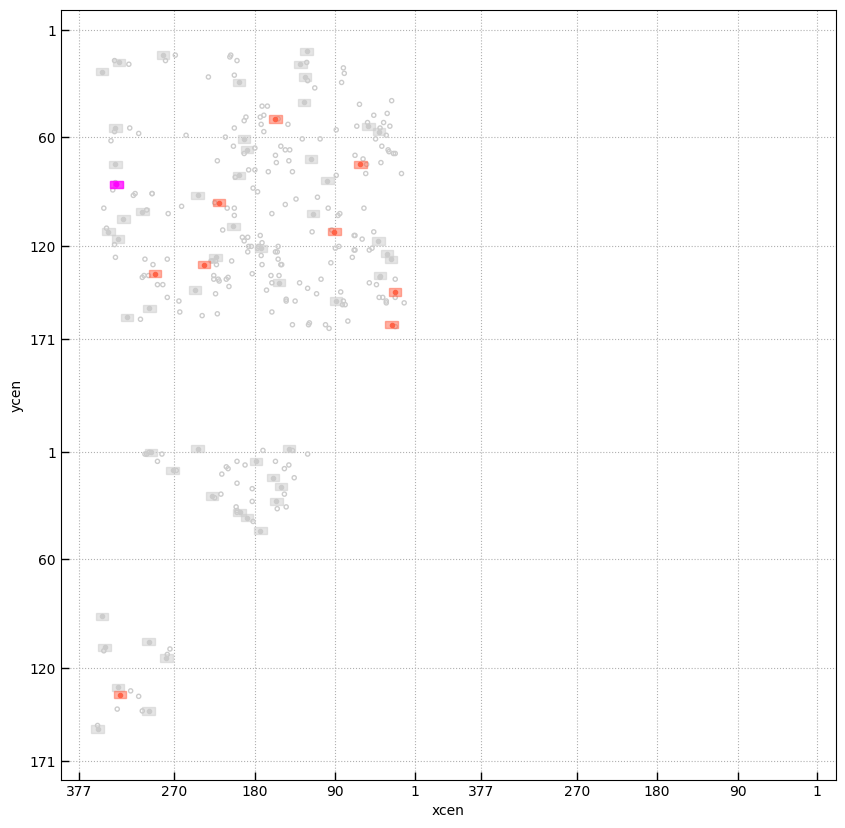

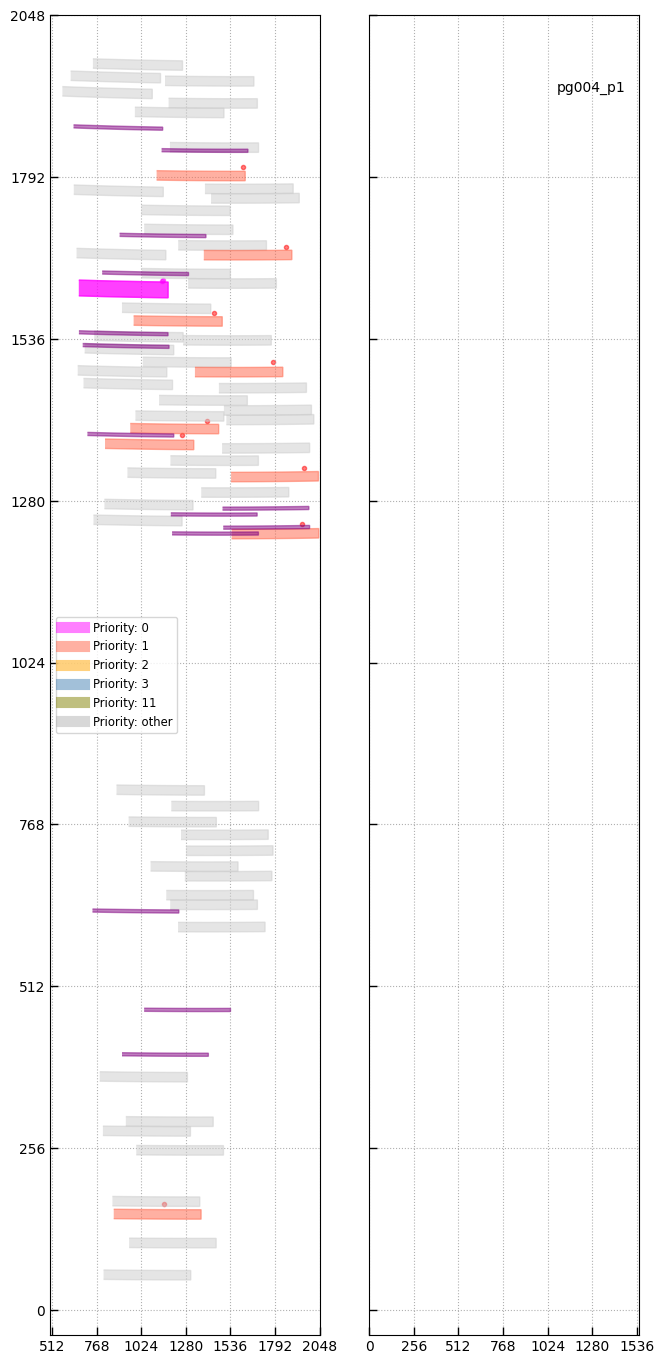

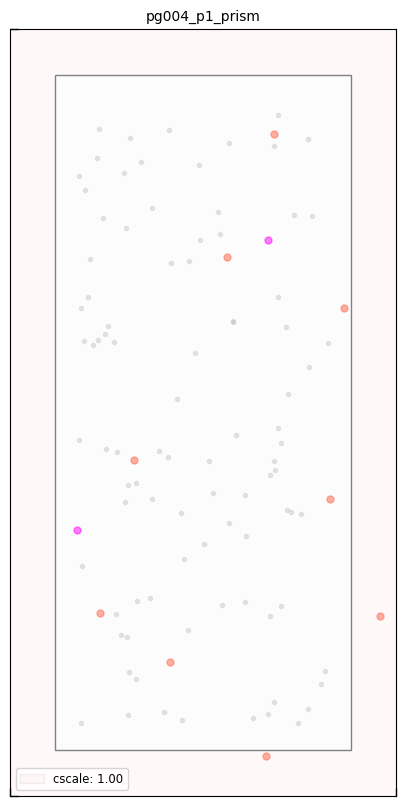

In [45]:
_ = prism_trace.write_outputs(allocated=allocated_prism, att=planner.mplan.att)

102
Keep 100 / 102 sources in ID list
pg004_p1_g395m.json
pg004_p1_g395m_shutters.csv


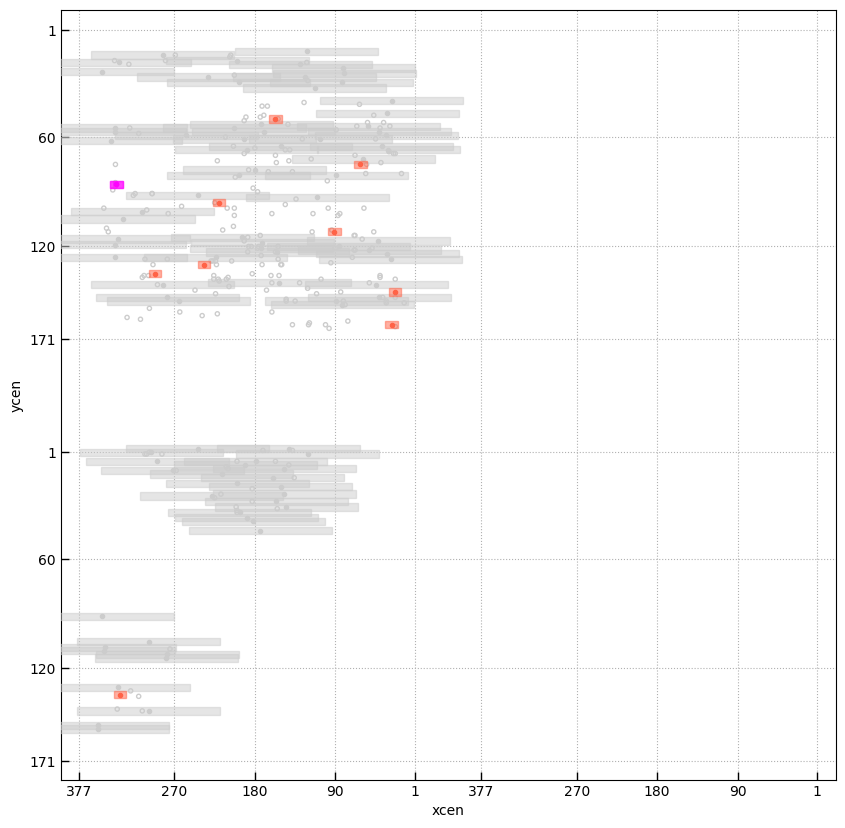

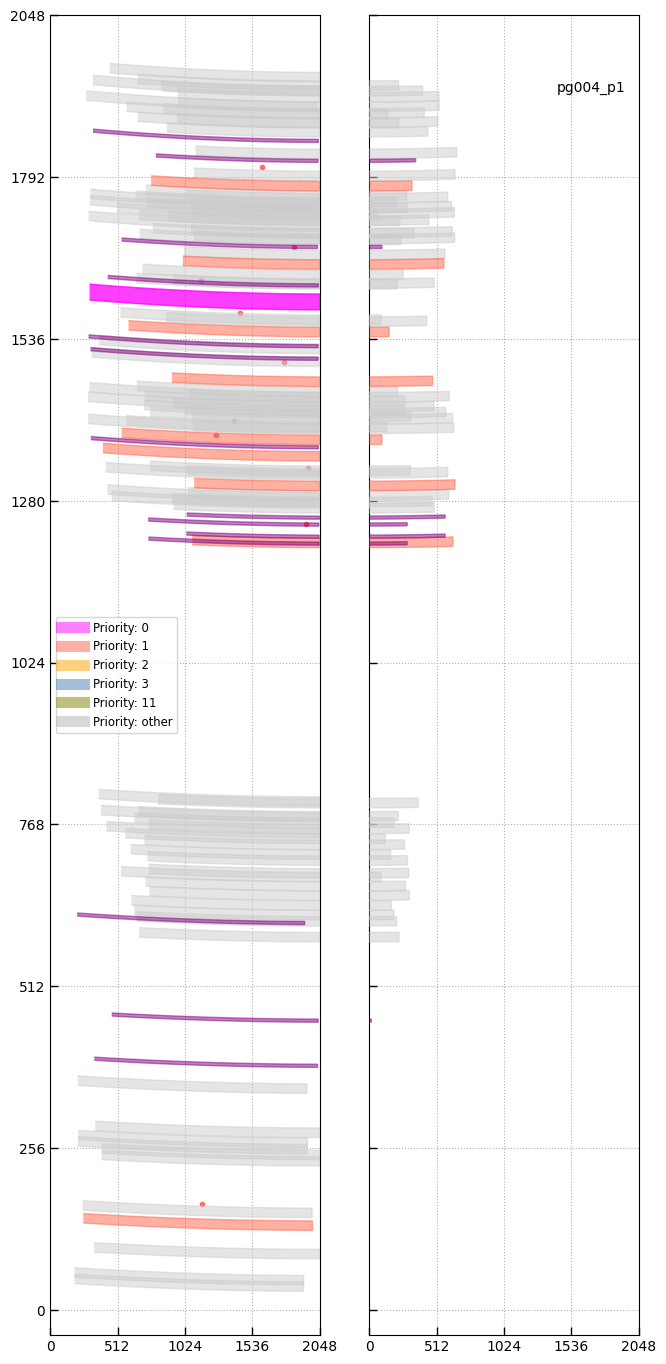

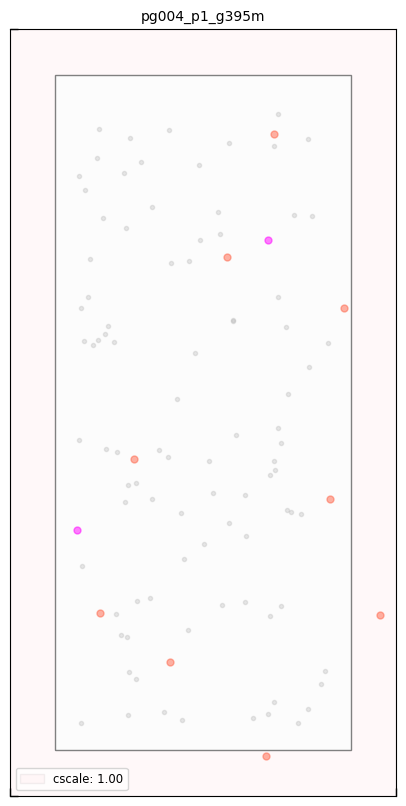

In [46]:
_ = grating_trace.write_outputs(allocated=allocated_grating, att=planner.mplan.att)

# Copy files to subdirectory

In [47]:
pointing, plan_version

('pg004_p1', 'pg004_202606.1')

In [48]:
if not os.path.exists(plan_version):
    os.makedirs(plan_version)

if plan_version.startswith("gnz7q2025"):
    commands = """
cp gnz7q_g395m.json gnz7q_g140m.json
perl -pi -e "s/G140M_F070LP/G395M_F290LP/g" gnz7q_g395m.json 
perl -pi -e "s/G395M_F290LP/G140M_F070LP/g" gnz7q_g140m.json 
perl -pi -e "s/g395m/g140m/g" gnz7q_g140m.json
"""
    for cmd in commands.strip().split("\n"):
        print(cmd)
        os.system(cmd)

else:
    ! cp {pointing}* {plan_version}/

! tar czf {plan_version}.tar.gz {plan_version}/
! cp {plan_version}.tar.gz /tmp/

In [49]:
! ls -1 {plan_version}/

pg004_p1.summary.txt
pg004_p1_g395m.json
pg004_p1_g395m.png
pg004_p1_g395m_centering.png
pg004_p1_g395m_msa.png
pg004_p1_g395m_shutters.csv
pg004_p1_prism.json
pg004_p1_prism.png
pg004_p1_prism_apt_centering.png
pg004_p1_prism_centering.png
pg004_p1_prism_msa.png
pg004_p1_prism_shutters.csv
pg004_p1_shutter_table.fits
pg004_p2.summary.txt
pg004_p2_g395m.json
pg004_p2_g395m.png
pg004_p2_g395m_centering.png
pg004_p2_g395m_msa.png
pg004_p2_g395m_shutters.csv
pg004_p2_prism.json
pg004_p2_prism.png
pg004_p2_prism_centering.png
pg004_p2_prism_msa.png
pg004_p2_prism_shutters.csv
pg004_p2_shutter_table.fits


In [50]:
! cat {plan_version}/{pointing}*txt

# p   Np  pure  grat  both
# N   298   65  102    54
# pg004_p1
P0      2    2    2     2
P1      9    9    9     9
P4    136   38   60    32
P6    151   16   31    11


In [51]:
final_shutters = utils.read_catalog("pg004_p1_shutter_table.fits")
final_shutters[final_shutters["ok_prism"]]

id,ix,shutter_quadrant,shutter_row,shutter_column,raw_row,raw_col,priority,ok_open,ok_prism,ok_grating,sltstrt1,sltstrt1_nrs1_prism,sltsize1,sltsize1_nrs1_prism,sltstrt2,sltstrt2_nrs1_prism,sltsize2,sltsize2_nrs1_prism,trace_c0,trace_c0_nrs1_prism,trace_c1,trace_c1_nrs1_prism,trace_c2,trace_c2_nrs1_prism,x_min,x_min_nrs1_prism,x_max,x_max_nrs1_prism,wave_min,wave_min_nrs1_prism,wave_max,wave_max_nrs1_prism,sltstrt1_nrs2_prism,sltsize1_nrs2_prism,sltstrt2_nrs2_prism,sltsize2_nrs2_prism,trace_c0_nrs2_prism,trace_c1_nrs2_prism,trace_c2_nrs2_prism,x_min_nrs2_prism,x_max_nrs2_prism,wave_min_nrs2_prism,wave_max_nrs2_prism,sltstrt1_nrs1_g395m,sltsize1_nrs1_g395m,sltstrt2_nrs1_g395m,sltsize2_nrs1_g395m,trace_c0_nrs1_g395m,trace_c1_nrs1_g395m,trace_c2_nrs1_g395m,x_min_nrs1_g395m,x_max_nrs1_g395m,wave_min_nrs1_g395m,wave_max_nrs1_g395m,sltstrt1_nrs2_g395m,sltsize1_nrs2_g395m,sltstrt2_nrs2_g395m,sltsize2_nrs2_g395m,trace_c0_nrs2_g395m,trace_c1_nrs2_g395m,trace_c2_nrs2_g395m,x_min_nrs2_g395m,x_max_nrs2_g395m,wave_min_nrs2_g395m,wave_max_nrs2_g395m
int32,int64,int64,int64,int64,float64,float64,int64,bool,bool,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
942,304,3,157,50,157.17110083100897,50.612371263461,1,False,True,True,1.0,1098.9444444444446,325.5,524.0,1767.0,1782.3888888888891,23.066666666666666,24.61111111111111,4.711817393333333e-06,4.9549864222222226e-06,0.00213996702,-0.0020456374333333335,11.844537666666668,12.365482944444445,0.00,13.94,324.50,523.00,5.04,0.50,5.62,5.76,--,--,--,--,--,--,--,--,--,--,--,768.5,1280.5,1766.0666666666666,32.56666666666667,4.9478878899999996e-06,-0.00694717745,14.90911205,0.00,1279.50,2.48,4.77,1.0,325.5,1767.0,23.066666666666666,4.711817393333333e-06,0.00213996702,11.844537666666668,0.00,324.50,5.04,5.62
1037,325,3,62,75,62.58519410427925,75.8251899152001,1,False,True,True,1.0,1371.0,567.2,520.0,1643.0000000000002,1657.0,25.000000000000004,24.0,4.5904849800000005e-06,4.660852666666666e-06,0.0031771519800000004,0.0007298200333333333,12.203723400000001,12.268506666666667,0.00,13.00,566.20,519.00,4.60,0.50,5.62,5.76,--,--,--,--,--,--,--,--,--,--,--,1008.6000000000001,1040.4,1643.0000000000002,28.000000000000004,4.71857514e-06,-0.005572647180000001,13.212999000000002,0.00,1039.40,2.48,4.34,1.0,567.2,1643.0000000000002,25.000000000000004,4.5904849800000005e-06,0.0031771519800000004,12.203723400000001,0.00,566.20,4.60,5.62
1992,580,3,91,112,91.43701582375866,112.29736485985245,1,False,True,True,1.0,1320.0,482.00000000000006,519.0,1457.0,1472.0,25.000000000000004,24.0,4.369972820000001e-06,4.462334e-06,0.0026560900600000005,0.00046510148,12.734826700000001,12.254554,0.00,13.00,481.00,518.00,4.76,0.50,5.62,5.76,--,--,--,--,--,--,--,--,--,--,--,925.6666666666667,1123.3333333333335,1457.0,30.000000000000004,4.5167122000000005e-06,-0.0056945704000000005,14.063693333333335,0.00,1122.33,2.48,4.49,1.0,482.00000000000006,1457.0,25.000000000000004,4.369972820000001e-06,0.0026560900600000005,12.734826700000001,0.00,481.00,4.76,5.62
2643,744,3,23,145,23.04197131112278,145.76463661703417,1,False,True,True,1.0,1527.1,651.75,516.6,1292.0,1306.0,26.0,25.0,4.21530255e-06,4.21692522e-06,0.0032669872,0.00239871141,13.044194,12.7246577,0.00,13.60,650.75,515.60,4.45,0.50,5.62,5.77,--,--,--,--,--,--,--,--,--,--,--,1095.5,953.5,1292.0,28.0,4.292852875e-06,-0.004723516325,13.62366675,0.00,952.50,2.48,4.19,1.0,651.75,1292.0,26.0,4.21530255e-06,0.0032669872,13.044194,0.00,650.75,4.45,5.62
2690,762,3,335,86,335.3311696744554,86.27535960447756,0,False,True,True,--,652.0,--,528.0,--,1602.0,--,27.0,--,5.0299786e-06,--,-0.006061725,--,13.641134

In [52]:
! ls -1 {plan_version}/*json

pg004_202606.1/pg004_p1_g395m.json
pg004_202606.1/pg004_p1_prism.json
pg004_202606.1/pg004_p2_g395m.json
pg004_202606.1/pg004_p2_prism.json


# Load the plan JSON file(s) in APT/MPT

- `APT -> MSA Planning Tool -> Plans -> Import Plan(s)`
- Hopefully no errors will be reported on the import!
- Double-check shutter centering of high priority targets
    - The APT intra-shutter view might be a little different than the planned view here if the offset is large.  The transformation here tries to preserve the details of the APA rotation, but it's not *perfect*.

<img src="pg004_p1_prism_centering.png" alt="this p1" width="200"/> <img src="pg004_p1_prism_apt_centering.png" alt="apt p1" width="250"/>
<img src="pg004_p2_prism_centering.png" alt="this p2" width="200"/> <img src="pg004_p2_prism_apt_centering.png" alt="apt p2" width="250"/>

- Highlight one or more masks and click `APT -> MSA Planning Tool -> Plans -> Update Observation` to attach them to an observation.
    - Can ignore "slit traces affected by failed open shutters" warnings if those overlaps were allowed
    - **Check for "The MSA plan has a configuration that is no longer valid" error.**  This tended to happen when my plan used a shutter that was stuck-closed in the APT shutter table, but it should be synced now.  That error could also appear if the APT shutter alignment wasn't exactly as expected and one or more sources violated the centering constraint of the shutter it was attached to in the plan file.
    - **Check MSATA** in the Observation pulldown!
        - Sufficient number of stars in one or more MSATA readout modes
        - Check the thumbnails of the sources themselves to ensure they are relatively bright, unsaturated, isolated!


# Update the planned shutter table

Useful for bookkeeping, checking individual sources included in the mask.

In [53]:
import glob

try:
    _ = planned_slitsx
    print('existing planned slits')
except:
    planned_slits = utils.GTable()
    planned_slits['id'] = nrs['ID']
    planned_slits['ra'] = nrs['RA']
    planned_slits['dec'] = nrs['Dec']
    
    planned_slits['has_prism'] = 0.0
    planned_slits['has_grating'] = 0.0
    
    un = utils.Unique(dja_spec['grating'])
    # idx, dr = dja_spec[un['G395M']].match_to_catalog_sky(planned_slits)
    # planned_slits['has_grating'][dr.value < 0.3] = 0.5
    if un['PRISM'].sum() > 0:
        idx, dr = dja_spec[un['PRISM']].match_to_catalog_sky(planned_slits)
        planned_slits['has_prism'][dr.value < 0.3] = 0.5

if 1:

    files = glob.glob(f'{plan_version}/*_shutter*fits')

    files.sort()

    prism_mask = ['']*len(planned_slits)
    grating_mask = ['']*len(planned_slits)
    
    for f in files:            
        print(f)
        sh = utils.read_catalog(f)
        hasp = np.isin(planned_slits['id'], sh['id'][sh['ok_prism']])
        hasg = np.isin(planned_slits['id'], sh['id'][sh['ok_grating']])
    
        key = os.path.basename(f).split('_shutter')[0]
        for j in np.where(hasp)[0]:
            prism_mask[j] += key + ' '
        for j in np.where(hasg)[0]:
            grating_mask[j] += key + ' '
            
        planned_slits['has_prism'][hasp] += 1
        planned_slits['has_grating'][hasg] += 1
    
    planned_slits['prism_mask'] = prism_mask
    planned_slits['grating_mask'] = grating_mask
    print((planned_slits['has_prism'] > 0).sum(), 'planned prism slits')
    print((planned_slits['has_grating'] > 0).sum(), 'planned grating slits')

pla = planned_slits['has_prism'] > 0



   N  value     
====  ==========
 290  G395M     
pg004_202606.1/pg004_p1_shutter_table.fits
pg004_202606.1/pg004_p2_shutter_table.fits
162 planned prism slits
228 planned grating slits


0
pg004_202606.1/pg004_p1_prism.json
pg004_202606.1/pg004_p2_prism.json
https://grizli-cutout.herokuapp.com/exposures?filters=F444W-CLEAR&output=csv&polygon=rect(289.26403,-33.50573,10)
pointing_layout_pg004_202606.1.csv


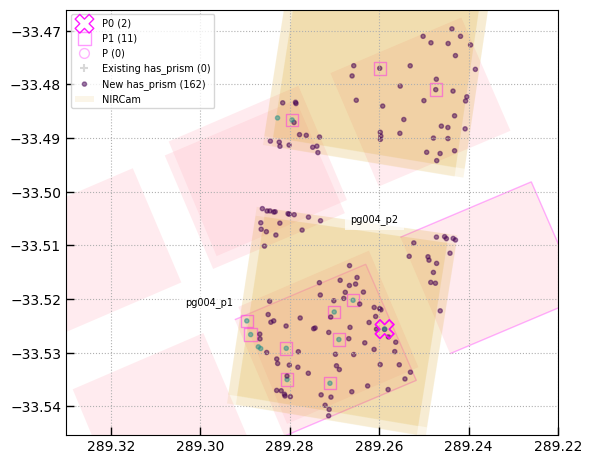

In [54]:
# alma = utils.read_catalog('as2uds_xmatch_primer-uds_imgv7.2_simple.txt', format='ascii')
# idx_alma, dr_alma = alma.match_to_catalog_sky(planned_slits)

SURVEY_FIELD = 'test'

np1 = np.isin(nrs['Priority'], [1.0])
np10 = nrs['Priority'] == 1.0
np0 = nrs['Priority'] < 0.5

if (0):
    plan_column = 'has_grating'
    files = glob.glob(f'{plan_version}/*_g*.json')
    files.sort()
else:
    plan_column = 'has_prism'
    files = glob.glob(f'{plan_version}/*prism.json')
    files.sort()

pla = planned_slits[plan_column] > 0
new_pla = planned_slits[plan_column] >= 0.8

np3 = np.isin(nrs['Priority'], [2, 2.5, 3.0]) & (~np1) & (~np0)
# np3 = np.isin(nrs['Priority'], [1.0])

p1_labels = ','.join([f'{p:.0f}' for p in np.unique(nrs['Priority'][np1])])
p3_labels = ','.join([f'{np.ceil(p):.0f}' for p in np.unique(np.ceil(nrs['Priority'][np3]))])

print(np3.sum())

if SURVEY_FIELD == 'UDS':
    fig, ax = plt.subplots(1,1,figsize=(10,6))
else:
    fig, ax = plt.subplots(1,1,figsize=(6,10))
    ax.set_aspect(1./np.cos(2./180*np.pi))

plt.scatter(planned_slits['ra'][np0 & pla], planned_slits['dec'][np0 & pla],
            alpha=0.9, ec='magenta',
            marker='X', fc='None', s=180, zorder=100,
            label=f'P0 ({(np0 & pla).sum()})',
)

if (np0 & ~pla).sum() > 0:
    plt.scatter(planned_slits['ra'][np0 & ~pla], planned_slits['dec'][np0 & ~pla],
            alpha=0.9,
            label=f'P0 missing ({(np0 & ~pla).sum()})',
            marker='X', fc='red', s=100, zorder=100,
    )

plt.scatter(planned_slits['ra'][np1 & new_pla], planned_slits['dec'][np1 & new_pla],
            alpha=0.4, s=80, marker='s', ec='magenta', fc='None',
            label='P' + p1_labels + f' ({(np1 & new_pla).sum()})',
)

plt.scatter(planned_slits['ra'][np1 & ~new_pla], planned_slits['dec'][np1 & ~new_pla],
            alpha=0.4, s=80, marker='s', ec='olive', fc='None',
            # label='P' + p1_labels,
)

plt.scatter(planned_slits['ra'][np3 & new_pla], planned_slits['dec'][np3 & new_pla],
            #alpha=0.1, color='0.5',
            alpha=0.3, s=50, marker='o', ec='magenta', fc='None',
            label='P'+p3_labels + f' ({(np3 & new_pla).sum()})',
)

plt.scatter(planned_slits['ra'][np3 & ~new_pla], planned_slits['dec'][np3 & ~new_pla],
            #alpha=0.1, color='0.5',
            alpha=0.3, s=50, marker='o', ec='olive', fc='None',
            # label='P'+p3_labels,
)

# print(np0.sum())

pre = (planned_slits[plan_column] - np.floor(planned_slits[plan_column])) == 0.5

plt.scatter(planned_slits['ra'][pre], planned_slits['dec'][pre],
            marker='+', color='0.5', alpha=0.3, zorder=-1000,
            label=f'Existing {plan_column} ({pre.sum()})',
)

plt.scatter(planned_slits['ra'][new_pla],
            planned_slits['dec'][new_pla],
            c=planned_slits[plan_column][new_pla],
            vmax=planned_slits[plan_column][new_pla].max()+1,
            marker='.',
            label=f'New {plan_column} ({new_pla.sum()})',
            alpha=0.5
)
    
if SURVEY_FIELD == 'UDS':
    plt.scatter(alma['ra'], alma['dec'], color='tomato', alpha=0.5, s=100, label='ALMA UDS')

plt.xlim(*plt.xlim()[::-1])

if SURVEY_FIELD == 'UDS':
    lens = utils.read_catalog("""# ra dec
34.4046030 -5.2246258
""")
elif 'cos_mom' in files[0]:
    inf = utils.read_catalog("""ra, dec
150.0592158, 2.2199638
""", format="csv")
    ax.scatter(inf['ra'], inf['dec'], marker='x', color='tomato', s=100, label='infty galaxy', zorder=-100)
    # ii, dd = awm.match_to_catalog_sky(inf)

# plt.scatter(lens['ra'], lens['dec'], marker='*', color='magenta', s=80)

ax = plt.gca()

for file in files:
        
    plan, corners = msaplan.utils.msa_quadrant_footprint(
        plan_file=file, ax=ax, patch_kwargs={'fc': 'pink', 'alpha': 0.3, 'ec': 'None', 'zorder':-100}
    )
    
    pxy = np.mean(np.hstack(corners), axis=1)
    label = os.path.basename(file).split('_prism')[0]

    ax.text(*pxy, label, ha='center', va='center', fontsize=7, bbox={'fc':'w', 'ec':'None', 'alpha':0.7})

yl = ax.get_ylim()
# try:
#     ax.scatter(gaia['ra'], gaia['dec'], s=np.interp(gaia['rpmag'], [9,18], [500,70]), ec='cyan', fc='None', label='GAIA')
# except NameError:
#     pass
    
ax.set_ylim(*yl)

ax.grid()
ax.set_aspect(1./np.cos(ax.get_ylim()[0]/180*np.pi))

# if '2744' in SURVEY_FIELD:
#     exposures = db.SQL("""
# select filter, footprint from exposure_files where polygon(circle(point(3.515,-30.37),0.1)) && polygon(footprint) AND instrume = 'NIRCAM'
# """)
    
#     for i, f in enumerate(exposures['footprint']):
#         sr = utils.SRegion(f)
#         sr.add_patch_to_axis(ax, zorder=-1000, color='olive', alpha=0.05, label='F814W' if i == 0 else None)

if (1):
    xl = ax.get_xlim()
    yl = ax.get_ylim()
    
    api_url = (
        f"https://grizli-cutout.herokuapp.com/exposures?filters=F444W-CLEAR&output=csv"
        f"&polygon=rect({np.mean(xl):.5f},{np.mean(yl):.5f},10)"
    )
    print(api_url)
    exposures = utils.read_catalog(api_url, format="csv")

    for i, row in enumerate(exposures):
        sr = utils.SRegion(row["footprint"])
        sr.add_patch_to_axis(
            ax,
            fc="goldenrod",
            ec="None",
            zorder=-100,
            alpha=0.1,
            label=("NIRCam" if i == 0 else None)
        )

ax.legend(fontsize=7)

if pointing.startswith("pg004"):
    ax.set_xlim(289.33, 289.22)

fig.tight_layout(pad=1)

print(f'pointing_layout_{plan_version}.csv')
fig.savefig(f'pointing_layout_{plan_version}.png')
planned_slits.write(f'pointing_layout_{plan_version}.csv', overwrite=True)

In [55]:
pointing = "pg004_p2"

**Done!**

Go up to [#Initialize offsets](#Initialize-offsets) and run again to generate a second pointing.